/tmp/ipykernel_2188/2981462205.py:148: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y_mean, 1)
/tmp/ipykernel_2188/2981462205.py:148: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y_mean, 1)
/tmp/ipykernel_2188/2981462205.py:148: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y_mean, 1)


Tersimpan: plot_hasil_simulasi.png  dan  plot_hasil_simulasi.pdf


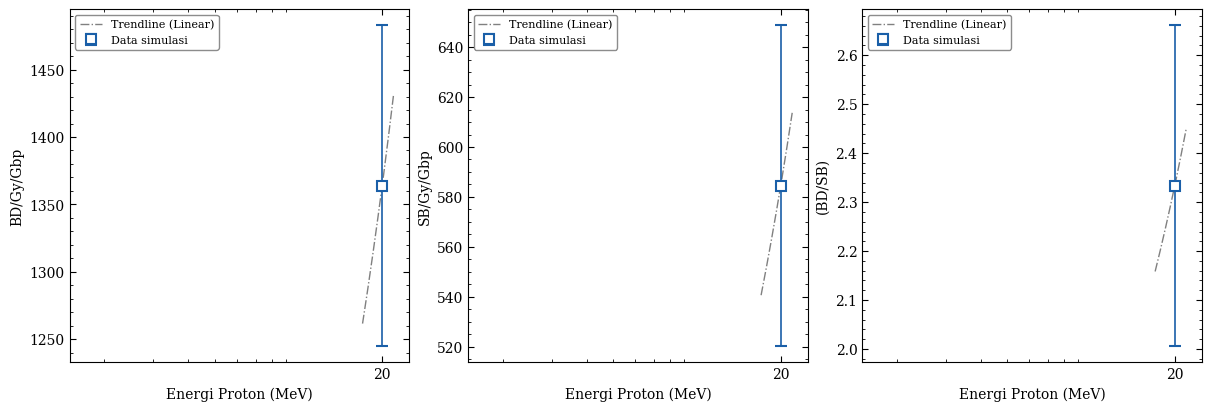

In [3]:
"""
Plot BD/Gy/Gbp, SB/Gy/Gbp, dan BD/SB vs energi proton
dari hasil simulasi TOPAS-nBio.

Struktur folder yang diharapkan:
    <direktori_kerja>/
        2MeV/hasil_simulasi.xlsx
        5MeV/hasil_simulasi.xlsx
        10MeV/hasil_simulasi.xlsx
        20MeV/hasil_simulasi.xlsx

Jalankan: python3 plot_simulasi.py
Output  : plot_hasil_simulasi.pdf (dan .png)
"""

import os
import numpy as np
import openpyxl
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Konfigurasi ──────────────────────────────────────────────────────────────
ENERGIES     = [20]          # MeV
ENERGY_DIRS  = ['outputs']
FILENAME     = "hasil_simulasi.xlsx"
DATA_ROWS    = (2, 45)                  # baris data (inklusif, 1-based)

# Indeks kolom (0-based) di sheet
COL_BD  = 9   # BD/Gy/Gbp  (kolom J)
COL_SB  = 5   # SB/Gy/Gbp  (kolom F)

# ── Style (meniru gambar referensi) ──────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.linewidth":   0.8,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

MARKER_STYLE = dict(
    marker="s",           # kotak seperti referensi
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#1a5fa8",
    markeredgewidth=1.5,
    color="#1a5fa8",
    linestyle="none",
    capsize=4,
    capthick=1.2,
    elinewidth=1.2,
    ecolor="#1a5fa8",
    zorder=5,
)

TREND_STYLE = dict(
    color="gray",
    linestyle="-.",
    linewidth=1.0,
    zorder=3,
)


# ── Fungsi baca data ──────────────────────────────────────────────────────────
def read_excel(filepath, col_idx, row_start, row_end):
    """Baca satu kolom dari Excel, kembalikan array numpy."""
    wb  = openpyxl.load_workbook(filepath, data_only=True)
    ws  = wb.active
    vals = []
    for row in ws.iter_rows(
        min_row=row_start, max_row=row_end, values_only=True
    ):
        v = row[col_idx]
        if v is not None:
            try:
                vals.append(float(v))
            except (TypeError, ValueError):
                pass
    return np.array(vals)


def collect_data():
    """
    Kembalikan dict:
        {
          'bd_mean', 'bd_std',
          'sb_mean', 'sb_std',
          'ratio_mean', 'ratio_std'   <- BD/SB dengan propagasi error
        }
    semua array panjang len(ENERGIES).
    """
    bd_mean, bd_std = [], []
    sb_mean, sb_std = [], []

    for folder in ENERGY_DIRS:
        path = os.path.join(folder, FILENAME)
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"File tidak ditemukan: {path}\n"
                f"Pastikan script dijalankan dari direktori yang berisi folder "
                f"{ENERGY_DIRS}"
            )

        bd_vals = read_excel(path, COL_BD, *DATA_ROWS)
        sb_vals = read_excel(path, COL_SB, *DATA_ROWS)

        bd_mean.append(bd_vals.mean())
        bd_std .append(bd_vals.std(ddof=1))
        sb_mean.append(sb_vals.mean())
        sb_std .append(sb_vals.std(ddof=1))

    bd_mean = np.array(bd_mean)
    bd_std  = np.array(bd_std)
    sb_mean = np.array(sb_mean)
    sb_std  = np.array(sb_std)

    # Propagasi error beruntun untuk rasio BD/SB:
    #   σ(R) = R * sqrt( (σ_BD/BD)² + (σ_SB/SB)² )
    ratio_mean = bd_mean / sb_mean
    ratio_std  = ratio_mean * np.sqrt(
        (bd_std / bd_mean) ** 2 + (sb_std / sb_mean) ** 2
    )

    return {
        "bd_mean":    bd_mean,
        "bd_std":     bd_std,
        "sb_mean":    sb_mean,
        "sb_std":     sb_std,
        "ratio_mean": ratio_mean,
        "ratio_std":  ratio_std,
    }


# ── Fungsi plot satu panel ────────────────────────────────────────────────────
def plot_panel(ax, x, y_mean, y_err, ylabel, add_trendline=True):
    # Error bar + marker
    ax.errorbar(x, y_mean, yerr=y_err, **MARKER_STYLE, label="Data simulasi")

    # Trendline linear
    if add_trendline:
        coeffs = np.polyfit(x, y_mean, 1)
        x_fit  = np.linspace(min(x) * 0.85, max(x) * 1.1, 200)
        y_fit  = np.polyval(coeffs, x_fit)
        ax.plot(x_fit, y_fit, **TREND_STYLE, label="Trendline (Linear)")

    # Sumbu
    ax.set_xlabel("Energi Proton (MeV)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim(1.5, 25)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xticks(ENERGIES)
    ax.tick_params(which="both", top=True, right=True)

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, frameon=True,
              framealpha=0.9, edgecolor="gray")


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    data = collect_data()
    x    = np.array(ENERGIES, dtype=float)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(12, 4),
        constrained_layout=True,
    )

    # Panel 1 – BD/Gy/Gbp
    plot_panel(
        axes[0], x,
        data["bd_mean"], data["bd_std"],
        ylabel="BD/Gy/Gbp",
    )

    # Panel 2 – SB/Gy/Gbp
    plot_panel(
        axes[1], x,
        data["sb_mean"], data["sb_std"],
        ylabel="SB/Gy/Gbp",
    )

    # Panel 3 – BD/SB
    plot_panel(
        axes[2], x,
        data["ratio_mean"], data["ratio_std"],
        ylabel="(BD/SB)",
    )

    # Simpan
    out_png = "plot_hasil_simulasi.png"
    out_pdf = "plot_hasil_simulasi.pdf"
    #fig.savefig(out_png, dpi=300, bbox_inches="tight")
    #fig.savefig(out_pdf, bbox_inches="tight")
    print(f"Tersimpan: {out_png}  dan  {out_pdf}")
    plt.show()


if __name__ == "__main__":
    main()

20 MeV | BD RE akhir: 0.0873 | SB RE akhir: 0.1099 | n=5

Tersimpan: plot_konvergensi.png  dan  plot_konvergensi.pdf


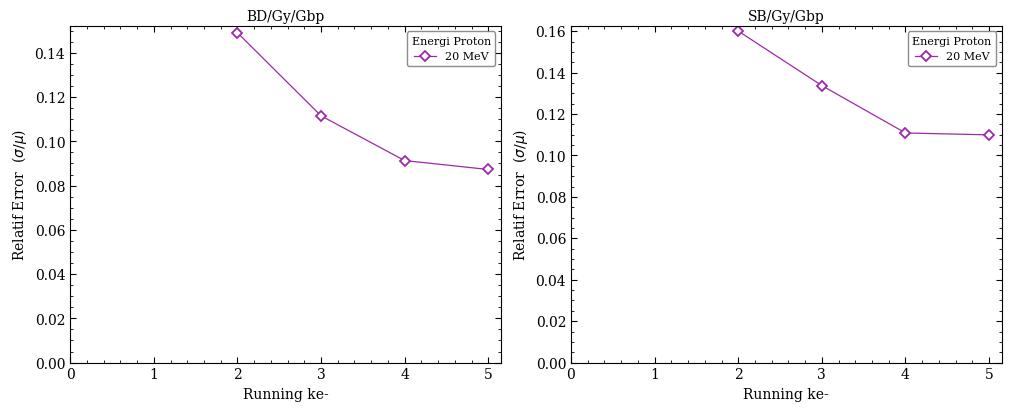

In [4]:
"""
Plot evolusi konvergensi (relatif error vs jumlah running) untuk BD/Gy/Gbp dan SB/Gy/Gbp,
menampilkan semua energi dalam satu grafik.

Relatif error pada running ke-n:
    RE(n) = std(data[1..n]) / mean(data[1..n])

Struktur folder yang diharapkan:
    <direktori_kerja>/
        2MeV/hasil_simulasi.xlsx
        5MeV/hasil_simulasi.xlsx
        10MeV/hasil_simulasi.xlsx
        20MeV/hasil_simulasi.xlsx

Jalankan: python3 plot_konvergensi.py
Output  : plot_konvergensi.png dan plot_konvergensi.pdf
"""

import os
import numpy as np
import openpyxl
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Konfigurasi ───────────────────────────────────────────────────────────────
ENERGIES    = [20]
ENERGY_DIRS = ['outputs']
FILENAME    = "hasil_simulasi.xlsx"
DATA_ROWS   = (2, 45)       # baris data inklusif (1-based)

COL_BD = 9   # kolom J: BD/Gy/Gbp
COL_SB = 5   # kolom F: SB/Gy/Gbp

# ── Style ─────────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":         "serif",
    "font.size":           10,
    "axes.linewidth":      0.8,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.major.size":    4,
    "ytick.major.size":    4,
    "xtick.minor.size":    2,
    "ytick.minor.size":    2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

# Warna dan marker berbeda untuk tiap energi
STYLES = {
    2:  {"color": "#1a5fa8", "marker": "s", "label": "2 MeV"},
    5:  {"color": "#e05c1a", "marker": "o", "label": "5 MeV"},
    10: {"color": "#2a9d40", "marker": "^", "label": "10 MeV"},
    20: {"color": "#9b2aa8", "marker": "D", "label": "20 MeV"},
}

COMMON_LINE = dict(
    linestyle="-",
    linewidth=0.9,
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.3,
)


# ── Fungsi baca satu kolom ────────────────────────────────────────────────────
def read_column(filepath, col_idx, row_start, row_end):
    wb   = openpyxl.load_workbook(filepath, data_only=True)
    ws   = wb.active
    vals = []
    for row in ws.iter_rows(
        min_row=row_start, max_row=row_end, values_only=True
    ):
        v = row[col_idx]
        if v is not None:
            try:
                vals.append(float(v))
            except (TypeError, ValueError):
                pass
    return np.array(vals)


# ── Hitung relatif error kumulatif ────────────────────────────────────────────
def cumulative_relative_error(data):
    """
    Untuk setiap n mulai dari 2 (std tidak terdefinisi untuk n=1),
    hitung RE(n) = std(data[:n], ddof=1) / mean(data[:n]).
    Kembalikan array x (indeks run, mulai dari 2) dan array RE.
    """
    n_total = len(data)
    x  = np.arange(2, n_total + 1)
    re = np.array([
        data[:n].std(ddof=1) / data[:n].mean()
        for n in x
    ])
    return x, re


# ── Plot satu panel ───────────────────────────────────────────────────────────
def plot_panel(ax, datasets, title_quantity):
    """
    datasets: list of (energy, x_arr, re_arr)
    """
    for energy, x_arr, re_arr in datasets:
        st = STYLES[energy]
        ax.plot(
            x_arr, re_arr,
            color=st["color"],
            marker=st["marker"],
            label=st["label"],
            markeredgecolor=st["color"],
            **COMMON_LINE,
        )

    ax.set_xlabel("Running ke-", fontsize=10)
    ax.set_ylabel(r"Relatif Error  ($\sigma / \mu$)", fontsize=10)
    ax.set_title(title_quantity, fontsize=10, pad=4)
    ax.tick_params(which="both", top=True, right=True)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.legend(fontsize=8, frameon=True, framealpha=0.9,
              edgecolor="gray", title="Energi Proton", title_fontsize=8)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    bd_datasets = []
    sb_datasets = []

    for energy, folder in zip(ENERGIES, ENERGY_DIRS):
        path = os.path.join(folder, FILENAME)
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"File tidak ditemukan: {path}\n"
                f"Jalankan script dari direktori yang berisi folder "
                f"{ENERGY_DIRS}."
            )

        bd_vals = read_column(path, COL_BD, *DATA_ROWS)
        sb_vals = read_column(path, COL_SB, *DATA_ROWS)

        x_bd, re_bd = cumulative_relative_error(bd_vals)
        x_sb, re_sb = cumulative_relative_error(sb_vals)

        bd_datasets.append((energy, x_bd, re_bd))
        sb_datasets.append((energy, x_sb, re_sb))

        print(f"{energy} MeV | BD RE akhir: {re_bd[-1]:.4f} | "
              f"SB RE akhir: {re_sb[-1]:.4f} | n={len(bd_vals)}")

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 4),
        constrained_layout=True,
    )

    plot_panel(axes[0], bd_datasets, "BD/Gy/Gbp")
    plot_panel(axes[1], sb_datasets, "SB/Gy/Gbp")

    #out_png = "plot_konvergensi.png"
    #out_pdf = "plot_konvergensi.pdf"
    #fig.savefig(out_png, dpi=300, bbox_inches="tight")
    #fig.savefig(out_pdf, bbox_inches="tight")
    print(f"\nTersimpan: {out_png}  dan  {out_pdf}")
    plt.show()


if __name__ == "__main__":
    main()